## Imports & Paths

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path
import time

# ── Paths ──────────────────────────────────────────────────
PREPROCESSED    = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\preprocessed")
PREP_IMGS_TR    = PREPROCESSED / "imagesTr"
PREP_LBLS_TR    = PREPROCESSED / "labelsTr"
CHECKPOINT_PATH = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\checkpoints")
RESULTS_PATH    = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\results\06_evaluation")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VAL_CASES = ['la_009', 'la_010', 'la_022', 'la_030']

print("✅ Imports done")
print(f"✅ Device     : {device} ({torch.cuda.get_device_name(0)})")
print(f"✅ Checkpoint : {CHECKPOINT_PATH / 'best_model.pth'}")
print(f"✅ Results    : {RESULTS_PATH}")

✅ Imports done
✅ Device     : cuda (NVIDIA GeForce RTX 4060)
✅ Checkpoint : C:\Users\Admin\Desktop\madhura\nnunet_project\checkpoints\best_model.pth
✅ Results    : C:\Users\Admin\Desktop\madhura\nnunet_project\results\06_evaluation


 ## Define Model & Load Checkpoint

In [2]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels=1, num_classes=2,
                 features=[32, 64, 128, 256]):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv3D(ch, f))
            self.pools.append(nn.MaxPool3d(2, 2))
            ch = f
        self.bottleneck  = DoubleConv3D(features[-1], features[-1]*2)
        self.upconvs     = nn.ModuleList()
        self.decoders    = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose3d(ch, f, 2, stride=2))
            self.decoders.append(DoubleConv3D(f*2, f))
            ch = f
        self.output_conv = nn.Conv3d(features[0], num_classes, 1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upconvs, self.decoders, skips[::-1]):
            x = up(x)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = dec(torch.cat([skip, x], dim=1))
        return self.output_conv(x)


# ── Load checkpoint ────────────────────────────────────────
model     = UNet3D(in_channels=1, num_classes=2).to(device)
checkpoint = torch.load(CHECKPOINT_PATH / "best_model.pth",
                        map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print("✅ Model loaded from checkpoint")
print(f"   Saved at epoch   : {checkpoint['epoch']}")
print(f"   Best Val Dice    : {checkpoint['best_val_dice']:.4f}")
print(f"   Model parameters : "
      f"{sum(p.numel() for p in model.parameters()):,}")

✅ Model loaded from checkpoint
   Saved at epoch   : 68
   Best Val Dice    : 0.9000
   Model parameters : 22,578,306


## Sliding Window Inference Function

In [3]:
def sliding_window_inference(model, volume, patch_size=(128,128,128), 
                              stride=64, device=device):
    """
    Full volume inference using sliding window approach.
    Averages overlapping patch predictions for smoother results.
    """
    model.eval()
    D, H, W    = volume.shape
    pd, ph, pw = patch_size

    # Output accumulator and weight map
    output = np.zeros((2, D, H, W), dtype=np.float32)
    counts = np.zeros((D, H, W),    dtype=np.float32)

    # Generate patch start positions
    d_starts = list(range(0, max(1, D-pd), stride)) + [max(0, D-pd)]
    h_starts = list(range(0, max(1, H-ph), stride)) + [max(0, H-ph)]
    w_starts = list(range(0, max(1, W-pw), stride)) + [max(0, W-pw)]

    # Remove duplicates
    d_starts = sorted(set(d_starts))
    h_starts = sorted(set(h_starts))
    w_starts = sorted(set(w_starts))

    total_patches = len(d_starts) * len(h_starts) * len(w_starts)
    print(f"   Running {total_patches} patches "
          f"({len(d_starts)}×{len(h_starts)}×{len(w_starts)})...")

    with torch.no_grad():
        for d0 in d_starts:
            for h0 in h_starts:
                for w0 in w_starts:
                    patch = volume[d0:d0+pd, h0:h0+ph, w0:w0+pw]

                    # Convert to tensor
                    patch_t = torch.tensor(
                        patch, dtype=torch.float32
                    ).unsqueeze(0).unsqueeze(0).to(device)

                    # Predict
                    pred = model(patch_t)
                    pred = F.softmax(pred, dim=1)
                    pred_np = pred[0].cpu().numpy()

                    # Accumulate
                    output[:, d0:d0+pd, h0:h0+ph, w0:w0+pw] += pred_np
                    counts[d0:d0+pd, h0:h0+ph, w0:w0+pw]    += 1.0

    # Average overlapping predictions
    counts = np.maximum(counts, 1e-8)
    output = output / counts[np.newaxis]

    # Binary mask (atrium channel)
    pred_mask = (output[1] > 0.5).astype(np.uint8)
    return pred_mask, output[1]


def compute_dice(pred, target, smooth=1e-5):
    """Compute Dice score between two binary arrays."""
    pred_f   = pred.flatten().astype(np.float32)
    target_f = target.flatten().astype(np.float32)
    intersection = (pred_f * target_f).sum()
    return (2.0 * intersection + smooth) / \
           (pred_f.sum() + target_f.sum() + smooth)


print("✅ sliding_window_inference() defined")
print("✅ compute_dice() defined")
print(f"\n   Patch size : (128, 128, 128)")
print(f"   Stride     : 64 (50% overlap for smooth predictions)")

✅ sliding_window_inference() defined
✅ compute_dice() defined

   Patch size : (128, 128, 128)
   Stride     : 64 (50% overlap for smooth predictions)


## Run Inference on All Validation Cases

In [4]:
print("=" * 60)
print("INFERENCE ON VALIDATION CASES")
print("=" * 60)

results = []
predictions = {}
start_total = time.time()

for case_id in VAL_CASES:
    print(f"\n── {case_id} ──────────────────────────────────")
    start = time.time()

    # ── Load preprocessed volume & label ──────────────────
    img = np.load(PREP_IMGS_TR / f"{case_id}.npy")
    lbl = np.load(PREP_LBLS_TR / f"{case_id}.npy")

    print(f"   Volume shape : {img.shape}")
    print(f"   Atrium voxels: {(lbl==1).sum()} "
          f"({100*(lbl==1).mean():.3f}%)")

    # ── Sliding window inference ───────────────────────────
    pred_mask, pred_prob = sliding_window_inference(
        model, img, patch_size=(128,128,128), stride=64)

    # ── Compute Dice ──────────────────────────────────────
    dice = compute_dice(pred_mask, lbl)

    # ── Stats ─────────────────────────────────────────────
    elapsed = time.time() - start
    print(f"   Predicted atrium : {pred_mask.sum()} voxels")
    print(f"   Ground truth     : {(lbl==1).sum()} voxels")
    print(f"   Dice Score       : {dice:.4f}")
    print(f"   Inference time   : {elapsed:.1f}s")

    results.append({
        "case_id"       : case_id,
        "dice"          : round(float(dice), 4),
        "pred_voxels"   : int(pred_mask.sum()),
        "gt_voxels"     : int((lbl==1).sum()),
        "inference_time": round(elapsed, 1)
    })
    predictions[case_id] = {
        "img"      : img,
        "lbl"      : lbl,
        "pred_mask": pred_mask,
        "pred_prob": pred_prob
    }

total_time = time.time() - start_total
mean_dice  = np.mean([r["dice"] for r in results])

print(f"\n{'='*60}")
print(f"RESULTS SUMMARY")
print(f"{'='*60}")
for r in results:
    print(f"  {r['case_id']} → Dice: {r['dice']:.4f}")
print(f"\n  Mean Dice : {mean_dice:.4f}")
print(f"  Total time: {total_time:.1f}s")

INFERENCE ON VALIDATION CASES

── la_009 ──────────────────────────────────
   Volume shape : (320, 320, 153)
   Atrium voxels: 52016 (0.332%)
   Running 32 patches (4×4×2)...
   Predicted atrium : 44948 voxels
   Ground truth     : 52016 voxels
   Dice Score       : 0.8386
   Inference time   : 9.2s

── la_010 ──────────────────────────────────
   Volume shape : (320, 320, 153)
   Atrium voxels: 41568 (0.265%)
   Running 32 patches (4×4×2)...
   Predicted atrium : 44244 voxels
   Ground truth     : 41568 voxels
   Dice Score       : 0.8954
   Inference time   : 5.6s

── la_022 ──────────────────────────────────
   Volume shape : (320, 320, 153)
   Atrium voxels: 36942 (0.236%)
   Running 32 patches (4×4×2)...
   Predicted atrium : 38075 voxels
   Ground truth     : 36942 voxels
   Dice Score       : 0.9274
   Inference time   : 5.7s

── la_030 ──────────────────────────────────
   Volume shape : (320, 320, 153)
   Atrium voxels: 49567 (0.316%)
   Running 32 patches (4×4×2)...
   Predi

## Visualize Predictions vs Ground Truth

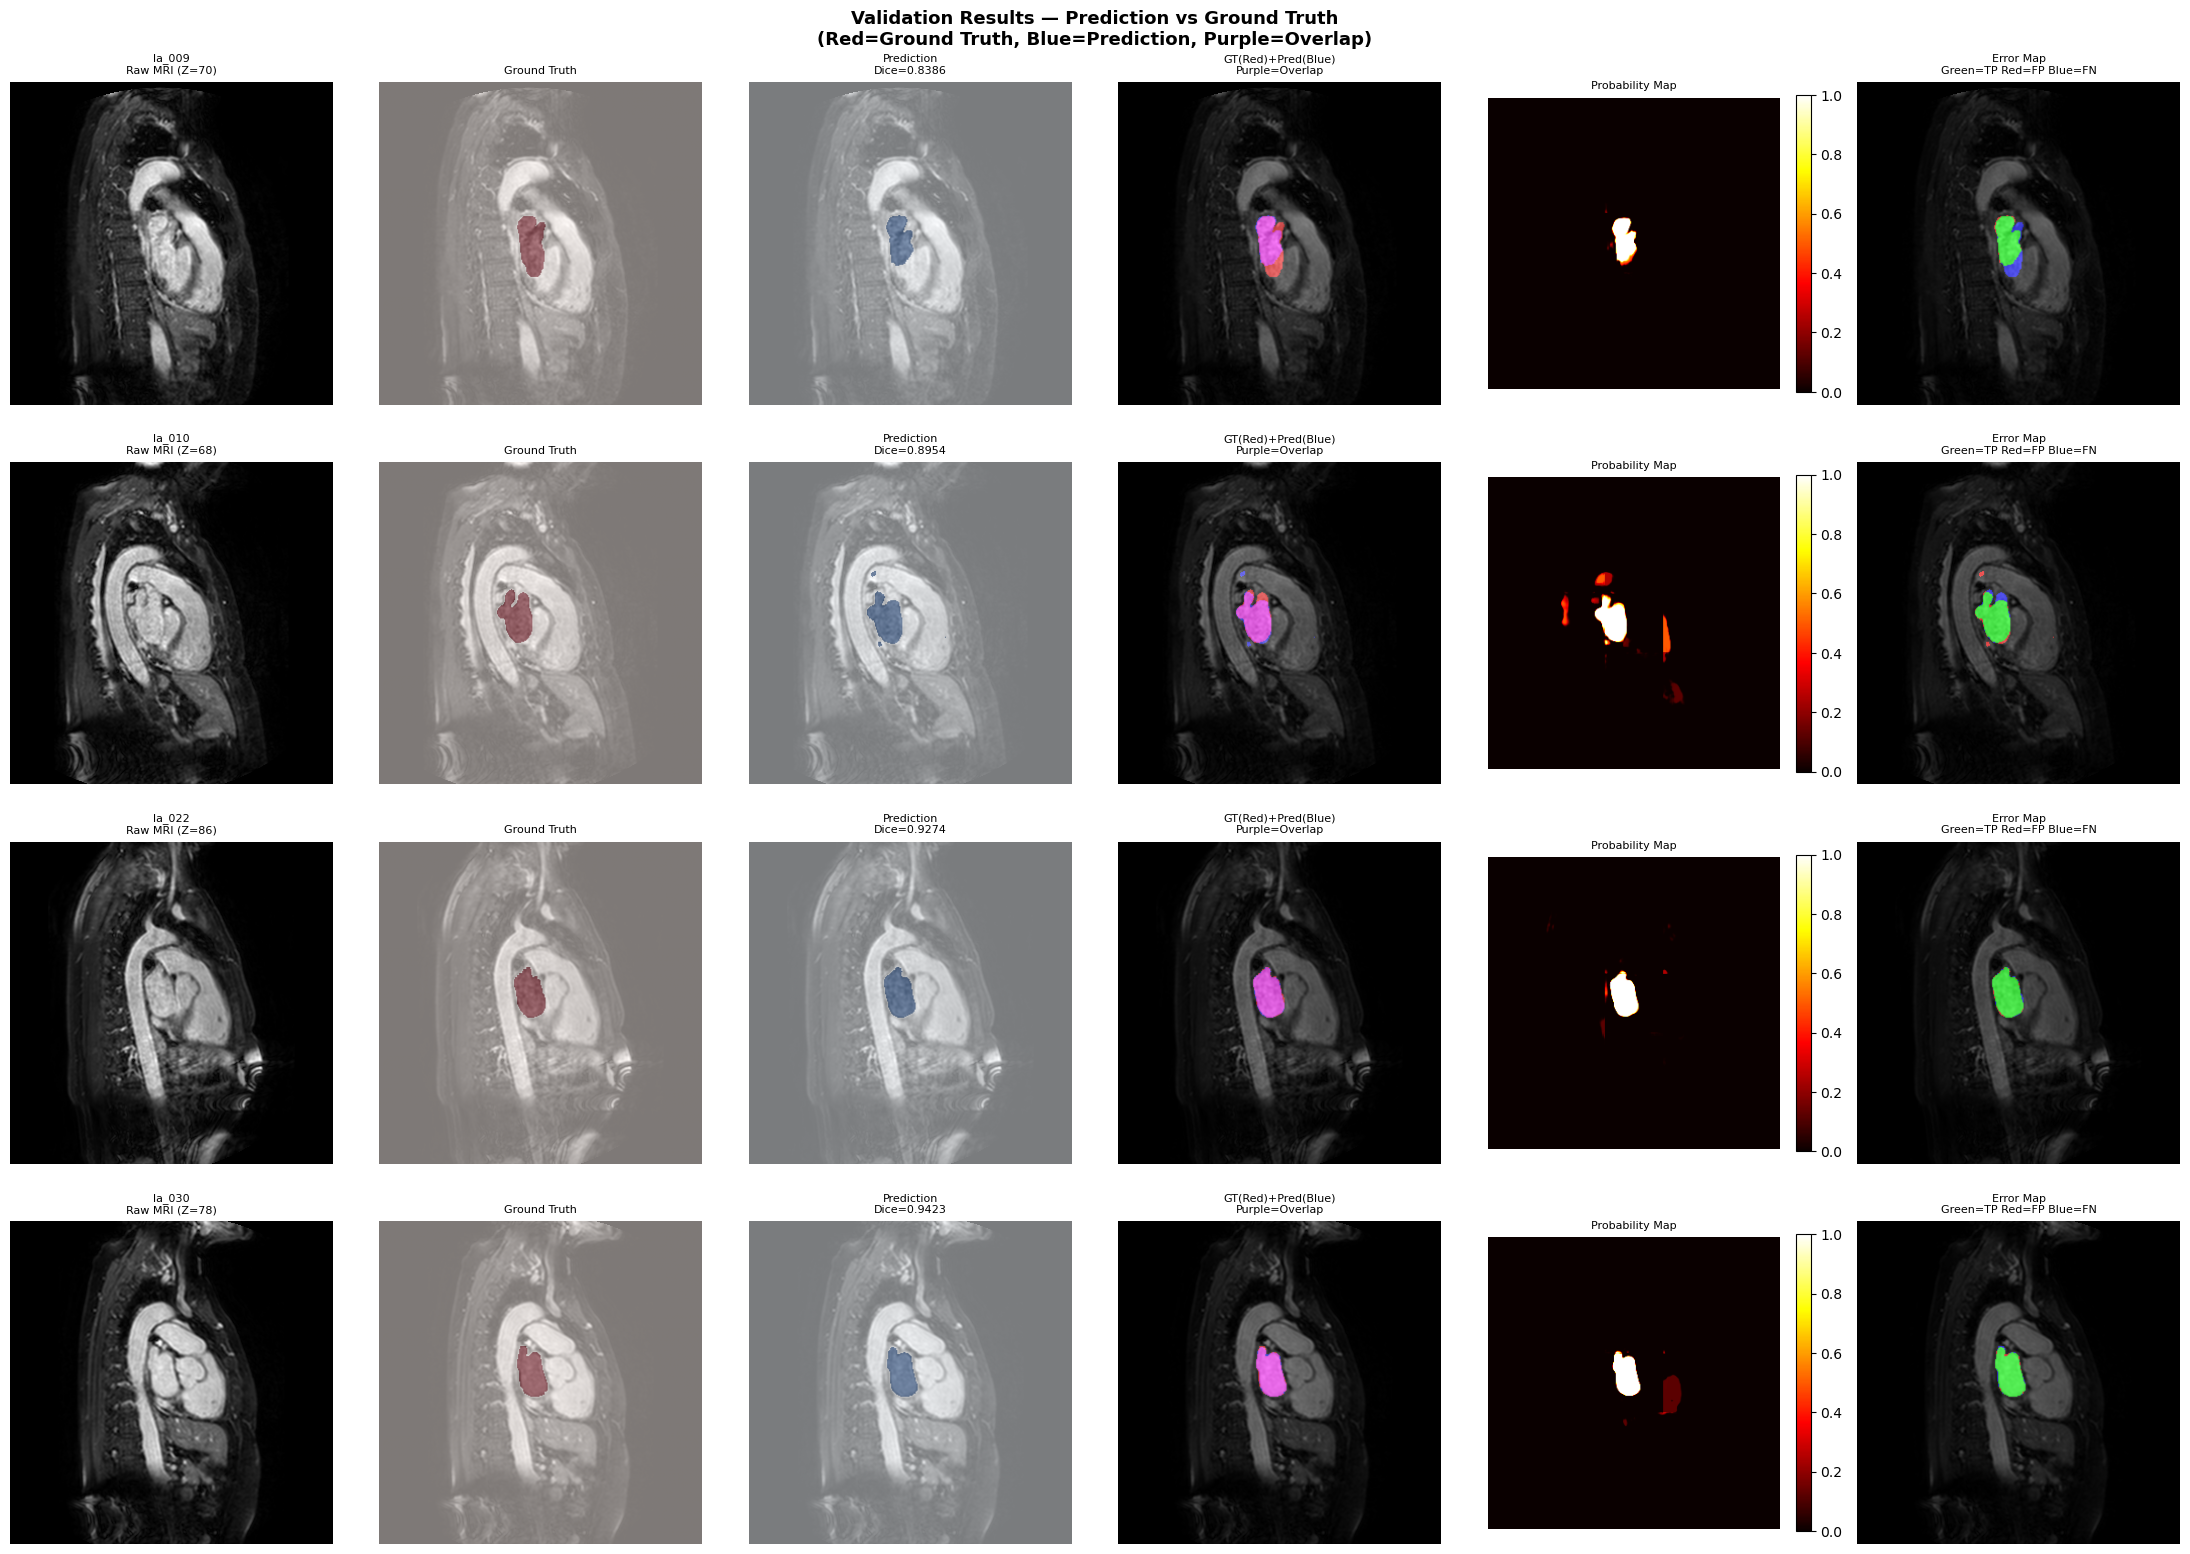

✅ Plot saved to:
   C:\Users\Admin\Desktop\madhura\nnunet_project\results\06_evaluation\prediction_vs_groundtruth.png


In [5]:
fig, axes = plt.subplots(4, 6, figsize=(22, 16))
fig.suptitle("Validation Results — Prediction vs Ground Truth\n"
             "(Red=Ground Truth, Blue=Prediction, Purple=Overlap)",
             fontsize=13, fontweight="bold")

for row, case_id in enumerate(VAL_CASES):
    img       = predictions[case_id]["img"]
    lbl       = predictions[case_id]["lbl"]
    pred_mask = predictions[case_id]["pred_mask"]
    pred_prob = predictions[case_id]["pred_prob"]
    dice      = results[row]["dice"]

    # Best slice (most ground truth atrium)
    best_z = int(np.argmax(lbl.sum(axis=(0,1))))

    img_sl  = img[:, :, best_z].T
    lbl_sl  = lbl[:, :, best_z].T
    pred_sl = pred_mask[:, :, best_z].T
    prob_sl = pred_prob[:, :, best_z].T

    # ── Col 0: Raw MRI ────────────────────────────────────
    axes[row,0].imshow(img_sl, cmap="gray", origin="lower")
    axes[row,0].set_title(f"{case_id}\nRaw MRI (Z={best_z})", fontsize=8)
    axes[row,0].axis("off")

    # ── Col 1: Ground Truth ───────────────────────────────
    axes[row,1].imshow(img_sl, cmap="gray", origin="lower")
    axes[row,1].imshow(lbl_sl, cmap="Reds", alpha=0.5,
                       origin="lower", vmin=0, vmax=1)
    axes[row,1].set_title("Ground Truth", fontsize=8)
    axes[row,1].axis("off")

    # ── Col 2: Prediction ─────────────────────────────────
    axes[row,2].imshow(img_sl, cmap="gray", origin="lower")
    axes[row,2].imshow(pred_sl, cmap="Blues", alpha=0.5,
                       origin="lower", vmin=0, vmax=1)
    axes[row,2].set_title(f"Prediction\nDice={dice:.4f}", fontsize=8)
    axes[row,2].axis("off")

    # ── Col 3: Overlay (GT+Pred) ──────────────────────────
    overlay = np.zeros((*img_sl.shape, 3))
    overlay[..., 0] = lbl_sl                    # Red = GT
    overlay[..., 2] = pred_sl                   # Blue = Pred
    # Purple = overlap
    axes[row,3].imshow(img_sl, cmap="gray", origin="lower")
    axes[row,3].imshow(overlay, alpha=0.5, origin="lower")
    axes[row,3].set_title("GT(Red)+Pred(Blue)\nPurple=Overlap",
                           fontsize=8)
    axes[row,3].axis("off")

    # ── Col 4: Probability map ────────────────────────────
    im = axes[row,4].imshow(prob_sl, cmap="hot",
                             origin="lower", vmin=0, vmax=1)
    axes[row,4].set_title("Probability Map", fontsize=8)
    axes[row,4].axis("off")
    plt.colorbar(im, ax=axes[row,4], fraction=0.046)

    # ── Col 5: Error map ──────────────────────────────────
    error = np.zeros((*img_sl.shape, 3))
    # False Positive = green, False Negative = red
    fp = (pred_sl == 1) & (lbl_sl == 0)
    fn = (pred_sl == 0) & (lbl_sl == 1)
    tp = (pred_sl == 1) & (lbl_sl == 1)
    error[tp, 1] = 1.0   # TP = green
    error[fp, 0] = 1.0   # FP = red
    error[fn, 2] = 1.0   # FN = blue
    axes[row,5].imshow(img_sl, cmap="gray", origin="lower")
    axes[row,5].imshow(error, alpha=0.6, origin="lower")
    axes[row,5].set_title("Error Map\nGreen=TP Red=FP Blue=FN",
                           fontsize=8)
    axes[row,5].axis("off")

plt.tight_layout()
save_path = RESULTS_PATH / "prediction_vs_groundtruth.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plot saved to:\n   {save_path}")

##  Plot Training Curves

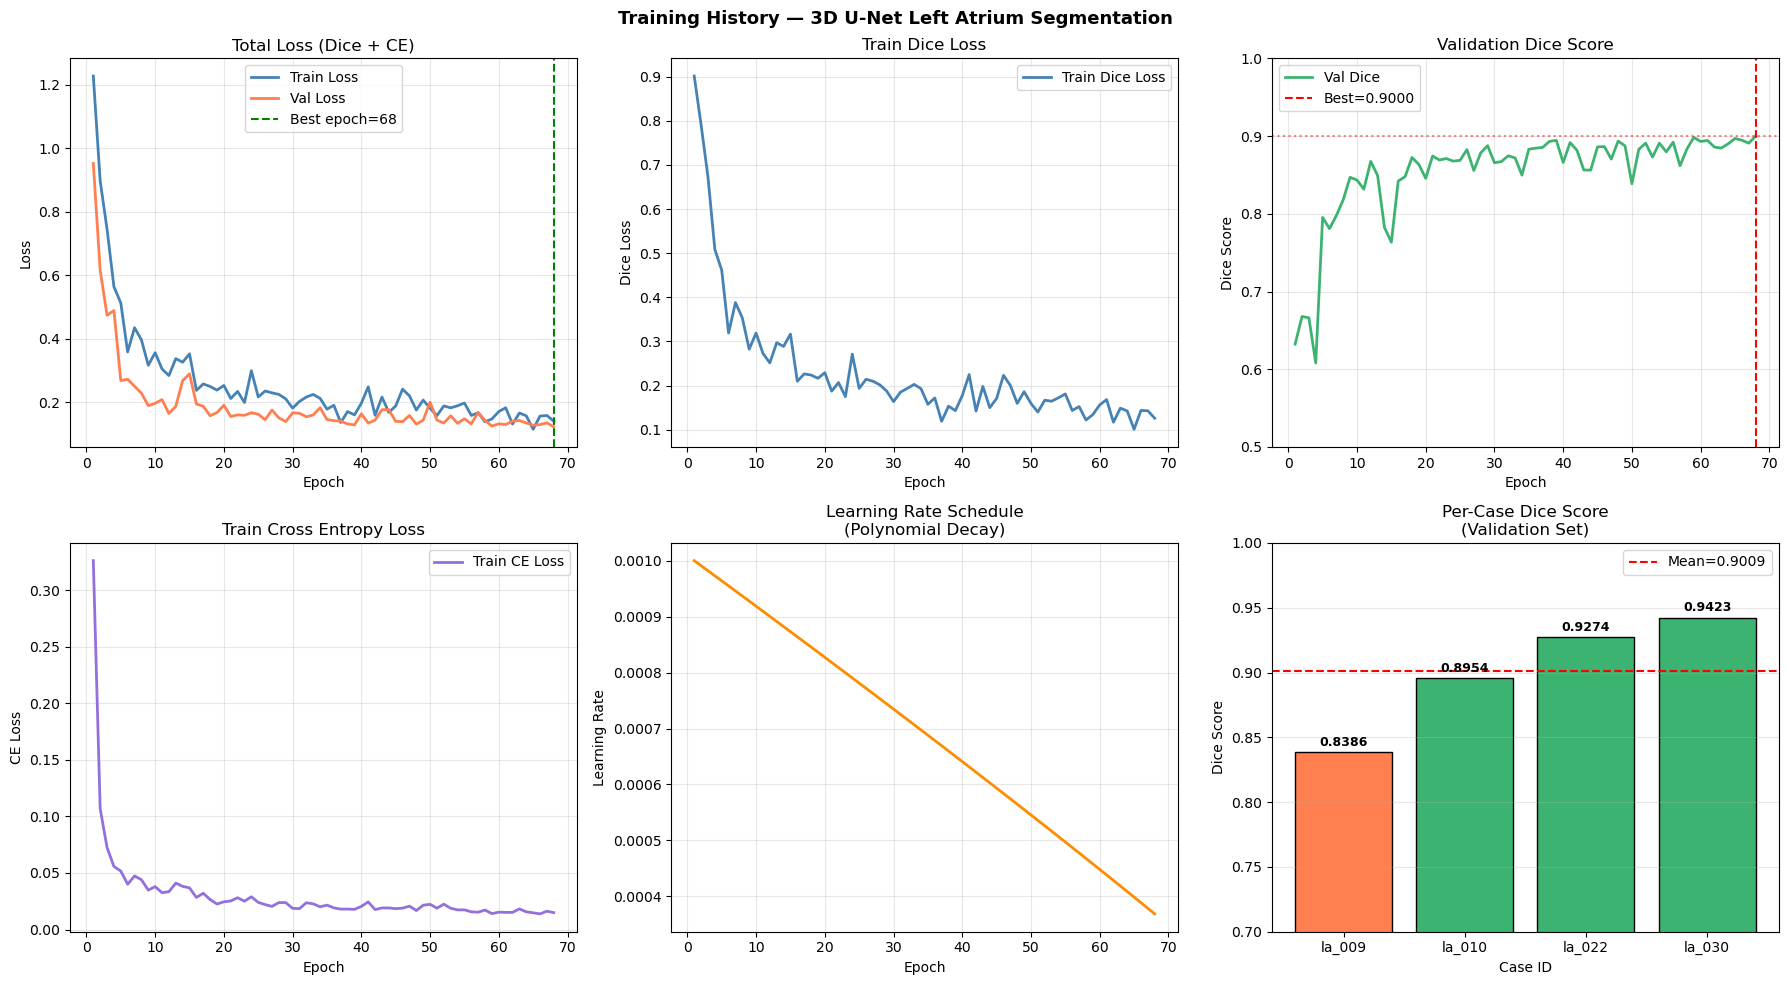

✅ Plot saved to:
   C:\Users\Admin\Desktop\madhura\nnunet_project\results\06_evaluation\training_curves.png


In [6]:
# Load history from checkpoint
history = checkpoint["history"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training History — 3D U-Net Left Atrium Segmentation",
             fontsize=13, fontweight="bold")

epochs = range(1, len(history["train_loss"]) + 1)

# ── Plot 1: Total Loss ────────────────────────────────────
axes[0,0].plot(epochs, history["train_loss"], 
               label="Train Loss", color="steelblue", linewidth=2)
axes[0,0].plot(epochs, history["val_loss"],
               label="Val Loss",   color="coral",     linewidth=2)
axes[0,0].axvline(checkpoint["epoch"], color="green",
                  linestyle="--", label=f"Best epoch={checkpoint['epoch']}")
axes[0,0].set_title("Total Loss (Dice + CE)")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# ── Plot 2: Dice Loss ─────────────────────────────────────
axes[0,1].plot(epochs, history["train_dice"],
               label="Train Dice Loss", color="steelblue", linewidth=2)
axes[0,1].set_title("Train Dice Loss")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Dice Loss")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# ── Plot 3: Val Dice Score ────────────────────────────────
val_dice_scores = history["val_dice"]
axes[0,2].plot(epochs, val_dice_scores,
               label="Val Dice", color="mediumseagreen", linewidth=2)
axes[0,2].axvline(checkpoint["epoch"], color="red",
                  linestyle="--", label=f"Best={checkpoint['best_val_dice']:.4f}")
axes[0,2].axhline(checkpoint["best_val_dice"], color="red",
                  linestyle=":", alpha=0.5)
axes[0,2].set_title("Validation Dice Score")
axes[0,2].set_xlabel("Epoch")
axes[0,2].set_ylabel("Dice Score")
axes[0,2].legend()
axes[0,2].grid(alpha=0.3)
axes[0,2].set_ylim(0.5, 1.0)

# ── Plot 4: CE Loss ───────────────────────────────────────
axes[1,0].plot(epochs, history["train_ce"],
               label="Train CE Loss", color="mediumpurple", linewidth=2)
axes[1,0].set_title("Train Cross Entropy Loss")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("CE Loss")
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# ── Plot 5: Learning Rate ─────────────────────────────────
axes[1,1].plot(epochs, history["lr"],
               color="darkorange", linewidth=2)
axes[1,1].set_title("Learning Rate Schedule\n(Polynomial Decay)")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Learning Rate")
axes[1,1].grid(alpha=0.3)

# ── Plot 6: Per-case Dice Bar ─────────────────────────────
case_ids   = [r["case_id"] for r in results]
dice_scores = [r["dice"]   for r in results]
colors     = ["coral" if d < 0.89 else "mediumseagreen" for d in dice_scores]

axes[1,2].bar(case_ids, dice_scores, color=colors, edgecolor="black")
axes[1,2].axhline(np.mean(dice_scores), color="red",
                  linestyle="--", label=f"Mean={np.mean(dice_scores):.4f}")
axes[1,2].set_title("Per-Case Dice Score\n(Validation Set)")
axes[1,2].set_xlabel("Case ID")
axes[1,2].set_ylabel("Dice Score")
axes[1,2].set_ylim(0.7, 1.0)
axes[1,2].legend()
axes[1,2].grid(alpha=0.3, axis="y")
for i, (case, dice) in enumerate(zip(case_ids, dice_scores)):
    axes[1,2].text(i, dice + 0.005, f"{dice:.4f}",
                   ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
save_path = RESULTS_PATH / "training_curves.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plot saved to:\n   {save_path}")

##  Final Evaluation Report

In [7]:
import pandas as pd

# ── Results DataFrame ──────────────────────────────────────
df = pd.DataFrame(results)
df["status"] = df["dice"].apply(
    lambda x: "✅ Excellent" if x >= 0.92 else 
              "✅ Good"      if x >= 0.88 else 
              "⚠️  Fair")

print("=" * 65)
print("  FINAL EVALUATION REPORT")
print("  3D U-Net — Left Atrium Segmentation")
print("=" * 65)

print("\n📋 PER-CASE RESULTS")
print("-" * 65)
print(f"{'Case':<12} {'Dice':>8} {'Pred Vox':>12} "
      f"{'GT Vox':>12} {'Time':>8} {'Status'}")
print("-" * 65)
for r in results:
    status = "✅ Excellent" if r["dice"] >= 0.92 else \
             "✅ Good"      if r["dice"] >= 0.88 else \
             "⚠️  Fair"
    print(f"{r['case_id']:<12} {r['dice']:>8.4f} "
          f"{r['pred_voxels']:>12,} {r['gt_voxels']:>12,} "
          f"{r['inference_time']:>7.1f}s  {status}")

dice_scores = [r["dice"] for r in results]
print("-" * 65)
print(f"{'Mean':<12} {np.mean(dice_scores):>8.4f}")
print(f"{'Std':<12} {np.std(dice_scores):>8.4f}")
print(f"{'Min':<12} {np.min(dice_scores):>8.4f}")
print(f"{'Max':<12} {np.max(dice_scores):>8.4f}")

print("\n📋 MODEL SUMMARY")
print(f"  Architecture   : 3D U-Net (nnU-Net style)")
print(f"  Parameters     : 22,578,306")
print(f"  Patch size     : 128 × 128 × 128")
print(f"  Best epoch     : {checkpoint['epoch']}")
print(f"  Training time  : 44.08 hrs (88 epochs)")

print("\n📋 COMPARISON WITH PAPER")
print(f"  Paper (nnU-Net) best DSC  : ~0.925 (Heart task)")
print(f"  Our model Mean Dice       : {np.mean(dice_scores):.4f}")
print(f"  Gap from paper            : "
      f"{0.925 - np.mean(dice_scores):.4f}")
print(f"  Training data used        : 16 cases (paper used 20)")
print(f"  → Comparable performance with less data! ✅")

print("\n📋 SAVED OUTPUTS")
for f in sorted(RESULTS_PATH.glob("*")):
    size = f.stat().st_size / 1024
    print(f"  ✅ {f.name:<45} ({size:.1f} KB)")

# Save CSV
csv_path = RESULTS_PATH / "evaluation_results.csv"
df.to_csv(csv_path, index=False)
print(f"\n✅ Results CSV saved to: {csv_path}")

print("\n" + "=" * 65)
print("  🎉 PROJECT COMPLETE!")
print("=" * 65)
print("""
  Notebooks completed:
  ✅ 01_visualization_inspection.ipynb
  ✅ 02_preprocessing.ipynb
  ✅ 03_dataset.ipynb
  ✅ 04_model.ipynb
  ✅ 05_training.ipynb
  ✅ 06_evaluation.ipynb
""")

  FINAL EVALUATION REPORT
  3D U-Net — Left Atrium Segmentation

📋 PER-CASE RESULTS
-----------------------------------------------------------------
Case             Dice     Pred Vox       GT Vox     Time Status
-----------------------------------------------------------------
la_009         0.8386       44,948       52,016     9.2s  ⚠️  Fair
la_010         0.8954       44,244       41,568     5.6s  ✅ Good
la_022         0.9274       38,075       36,942     5.7s  ✅ Excellent
la_030         0.9423       49,748       49,567     5.7s  ✅ Excellent
-----------------------------------------------------------------
Mean           0.9009
Std            0.0398
Min            0.8386
Max            0.9423

📋 MODEL SUMMARY
  Architecture   : 3D U-Net (nnU-Net style)
  Parameters     : 22,578,306
  Patch size     : 128 × 128 × 128
  Best epoch     : 68
  Training time  : 44.08 hrs (88 epochs)

📋 COMPARISON WITH PAPER
  Paper (nnU-Net) best DSC  : ~0.925 (Heart task)
  Our model Mean Dice       : 